In [2]:
import pandas as pd

data = {
    "tenure": [1, 5, 10, 2, 8, 12, 3, 7, 15, 6],
    "monthly_charges": [70, 50, 30, 80, 40, 20, 75, 45, 25, 55],
    "support_calls": [5, 1, 0, 6, None, 0, 4, 1, 0, 2],
    "contract_type": ["monthly", "yearly", "yearly", "monthly", "yearly", "yearly", "monthly", "yearly", "yearly", "monthly"],
    "churn": [1, 0, 0, 1, 0, 0, 1, 0, 0, 1]
}

df = pd.DataFrame(data)

In [3]:
df.head()

,tenure,monthly_charges,support_calls,contract_type,churn
0,1,70,5.0,monthly,1
1,5,50,1.0,yearly,0
2,10,30,0.0,yearly,0
3,2,80,6.0,monthly,1
4,8,40,NaN,yearly,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           10 non-null     int64  
 1   monthly_charges  10 non-null     int64  
 2   support_calls    9 non-null      float64
 3   contract_type    10 non-null     str    
 4   churn            10 non-null     int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 596.0 bytes


In [5]:
df.isnull().sum()

tenure             0
monthly_charges    0
support_calls      1
contract_type      0
churn              0
dtype: int64

In [6]:
df['support_calls'] = df['support_calls'].fillna(df['support_calls'].median())

In [7]:
df.isnull().sum()

tenure             0
monthly_charges    0
support_calls      0
contract_type      0
churn              0
dtype: int64

In [8]:
df['support_calls']

0    5.0
1    1.0
2    0.0
3    6.0
4    1.0
5    0.0
6    4.0
7    1.0
8    0.0
9    2.0
Name: support_calls, dtype: float64

In [9]:
df.columns

Index(['tenure', 'monthly_charges', 'support_calls', 'contract_type', 'churn'], dtype='str')

In [15]:
categorical_cols = ["contract_type"]
numerical_cols = ["tenure", "monthly_charges", "support_calls"]

In [22]:
X = df.drop('churn', axis=1)
y= df['churn']

print("X",X.shape)
print('y',y.shape)

X (10, 4)
y (10,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(use_label_encoder=False, eval_metric='logloss',random_state=42))
])

In [34]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [35]:
y_pred = pipeline.predict(X_test)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [29]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[2, 1],
       [0, 0]])

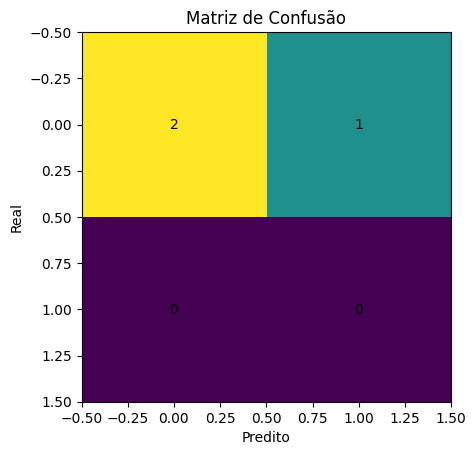

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()